In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.stats import pointbiserialr
from scipy.spatial.distance import pdist
from sklearn.preprocessing import LabelEncoder


# Clustering Correlation

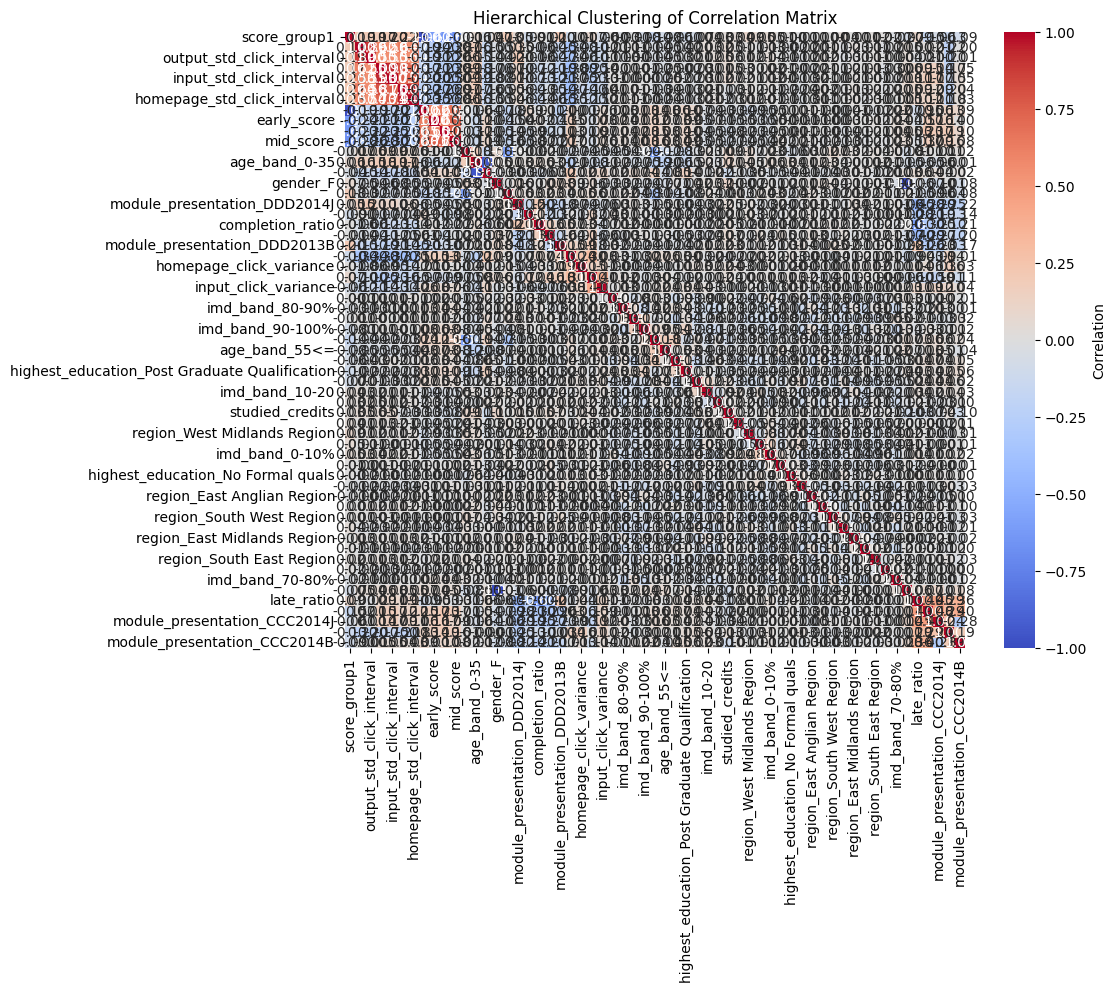

In [3]:
clustering_method = 'average'  # 可選擇 'single', 'complete', 'average', 'ward'

# Step 1: 讀取資料並進行分組
df = pd.read_csv("data.csv")
df = pd.get_dummies(df)  

# 計算 Pearson 相關矩陣（數值變數）
corr_matrix = df.corr(method='pearson')
corr_matrix = corr_matrix.fillna(0)  # 將 NaN 替換為 0

# Step 4: 進行階層分群並重新排列
# 先將相關矩陣轉為距離矩陣（1-相關性），因為階層分群使用的是距離
distance_matrix = 1 - corr_matrix

# 使用 linkage 計算階層分群，方法可以選擇 "average", "single", "complete" 等
Z = linkage(pdist(distance_matrix), method=clustering_method)

# 根據階層分群的結果排序相關矩陣
dendro = dendrogram(Z, no_plot=True)
ordered_idx = dendro['leaves']

# 重新排列相關矩陣
ordered_corr_matrix = corr_matrix.iloc[ordered_idx, ordered_idx]

# 儲存排序後的結果到 clustcorr.csv
ordered_corr_matrix.to_csv(f'clustcorr_{clustering_method}.csv')

# Step 5: 畫色溫圖
plt.figure(figsize=(10, 8))
sns.heatmap(ordered_corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar_kws={'label': 'Correlation'})
plt.title('Hierarchical Clustering of Correlation Matrix')
plt.show()


In [4]:
low_group = df[df['score'] == 'group1']
high_group = df[df['score'] == 'group3']

In [5]:
low_group.describe()

,studied_credits,date_registration,late_ratio,completion_ratio,navigation_mean_click_interval,navigation_std_click_interval,navigation_mean_clicks,navigation_click_variance,input_mean_click_interval,input_std_click_interval,input_mean_clicks,input_click_variance,output_mean_click_interval,output_std_click_interval,output_mean_clicks,output_click_variance,early_score,late_score,mid_score
count,1437.000000,1437.000000,1437.000000,1437.000000,1437.000000,1437.000000,1437.000000,1437.000000,1437.000000,1437.000000,1437.000000,1437.000000,1437.000000,1437.000000,1437.000000,1437.000000,1437.000000,1437.000000,1437.000000
mean,76.983299,-73.193459,0.446378,0.931945,4.024515,4.444100,5.307631,1.005806,6.834477,7.964889,6.356177,1.092551,10.183767,13.065782,13.611926,1.020411,70.392670,52.509974,61.743459
std,36.454054,51.477029,0.313499,0.137800,2.274498,2.804271,2.185025,0.292005,4.672766,5.043701,4.270223,0.408307,10.181721,13.625529,12.235523,0.284259,13.048838,18.952865,15.919184
min,30.000000,-310.000000,0.000000,0.375000,1.044898,0.207504,1.754717,0.468486,1.049383,0.217113,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,17.333333,0.000000,8.000000
25%,60.000000,-106.000000,0.166667,0.923077,2.469027,2.520196,3.881720,0.872401,3.819672,4.420646,4.029412,0.852131,4.288136,5.132233,5.281690,0.831688,62.400000,39.000000,50.800000
50%,60.000000,-59.000000,0.500000,1.000000,3.492754,3.768541,4.894118,0.972513,5.609756,6.824650,5.680000,1.021376,7.166667,9.388351,7.893617,0.988240,71.666667,52.000000,62.666667
75%,90.000000,-30.000000,0.636364,1.000000,4.980000,5.755547,6.232558,1.106534,8.461538,10.178820,7.641509,1.230465,12.105263,16.228918,19.611111,1.178122,79.600000,67.000000,73.600000
max,280.000000,49.000000,1.000000,1.000000,19.400000,22.706001,39.487603,9.083479,64.666667,42.522935,54.261905,5.391356,105.500000,139.300036,107.524590,2.674410,100.000000,99.000000,98.000000


In [6]:
high_group.describe()

,studied_credits,date_registration,late_ratio,completion_ratio,navigation_mean_click_interval,navigation_std_click_interval,navigation_mean_clicks,navigation_click_variance,input_mean_click_interval,input_std_click_interval,input_mean_clicks,input_click_variance,output_mean_click_interval,output_std_click_interval,output_mean_clicks,output_click_variance,early_score,late_score,mid_score
count,1374.000000,1374.000000,1374.000000,1374.000000,1374.000000,1374.000000,1374.000000,1374.000000,1374.000000,1374.000000,1374.000000,1374.000000,1374.000000,1374.000000,1374.000000,1374.000000,1374.000000,1374.000000,1374.000000
mean,75.072780,-71.475983,0.390402,0.929597,3.052864,3.133544,5.603962,0.998845,5.926118,6.734064,5.530251,1.185489,6.846228,8.628244,17.736785,1.100672,88.150328,82.130155,86.775849
std,32.856734,50.708044,0.334904,0.159159,1.719691,2.147806,2.338375,0.199424,4.117902,4.422222,4.423072,0.524315,6.873793,9.415293,14.888843,0.322086,8.804363,15.592255,10.332508
min,30.000000,-303.000000,0.000000,0.375000,1.000000,0.000000,1.833333,0.559576,1.053279,0.259053,1.076923,0.247436,1.015038,0.136063,1.600000,0.202031,36.500000,4.000000,24.000000
25%,60.000000,-103.000000,0.000000,1.000000,1.899497,1.687625,4.154600,0.876371,3.308472,3.591643,3.257698,0.901825,2.948181,3.211129,6.321647,0.871083,83.500000,76.000000,82.333333
50%,60.000000,-57.000000,0.500000,1.000000,2.612205,2.615390,5.139629,0.975022,4.686275,5.536378,4.763305,1.077999,4.869056,5.976799,13.472385,1.051127,89.666667,86.000000,89.333333
75%,90.000000,-30.000000,0.571429,1.000000,3.666667,3.994981,6.436458,1.083186,7.222899,8.689522,6.442459,1.310991,8.321071,11.195271,24.554444,1.261232,94.333333,93.000000,94.000000
max,270.000000,23.000000,1.000000,1.000000,16.266667,16.036639,33.728571,3.482904,38.800000,33.848190,72.935484,8.315850,81.000000,132.213212,105.500000,4.059936,100.000000,100.000000,100.000000
